In [1]:
# # Домашнее задание №5–6. Baseline-решение для DeepFake-детекции
# 
# ## Проект: DeepFake-детекция для медиа-безопасности
# 
# ### Цель работы:
# Построить baseline-модели для бинарной классификации видео (Real vs Fake) на основе данных FaceForensics++.
# 
# ### Задачи:
# 1. Загрузка и очистка данных
# 2. Анализ данных (EDA)
# 3. Обучение 2-3 простых моделей + 1 усложнённой
# 4. Оценка метрик (AUC, F1, Precision, Recall) и совокупной метрики качества
# 
# ### Используемые данные:
# - FaceForensics++ (5,000 видео: 20% real, 80% fake)
# - Признаки: средние значения RGB по кадрам (имитация для демонстрации пайплайна)

# ## 1. Загрузка и очистка данных

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
print("Библиотеки загружены")

Библиотеки загружены


In [2]:
# Создание синтетического датасета для демонстрации пайплайна
# В реальном проекте данные загружаются из FaceForensics++ через cv2.VideoCapture

np.random.seed(42)
n_samples = 2000
n_features = 10  # количество признаков (для демонстрации)

# Реальные видео (класс 0)
X_real = np.random.normal(0.5, 0.1, (n_samples//2, n_features))
y_real = np.zeros(n_samples//2)

# Фейковые видео (класс 1) — смещённые значения
X_fake = np.random.normal(0.55, 0.12, (n_samples//2, n_features))
y_fake = np.ones(n_samples//2)

X = np.vstack([X_real, X_fake])
y = np.hstack([y_real, y_fake])

print(f"Размер признаков: {X.shape}")
print(f"Размер меток: {y.shape}")
print(f"Real: {(y==0).sum()}, Fake: {(y==1).sum()}")

Размер признаков: (2000, 10)
Размер меток: (2000,)
Real: 1000, Fake: 1000


In [3]:
# Очистка данных: удаление выбросов (метод IQR)
def remove_outliers(X, y):
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = np.all((X >= lower_bound) & (X <= upper_bound), axis=1)
    print(f"Удалено выбросов: {len(X) - mask.sum()}")
    return X[mask], y[mask]

X_clean, y_clean = remove_outliers(X, y)

# %%
# Разделение на train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, y_clean, test_size=0.3, stratify=y_clean, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Удалено выбросов: 187
Train: 1269 samples
Validation: 272 samples
Test: 272 samples


In [4]:
# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Данные нормализованы (StandardScaler)")

Данные нормализованы (StandardScaler)


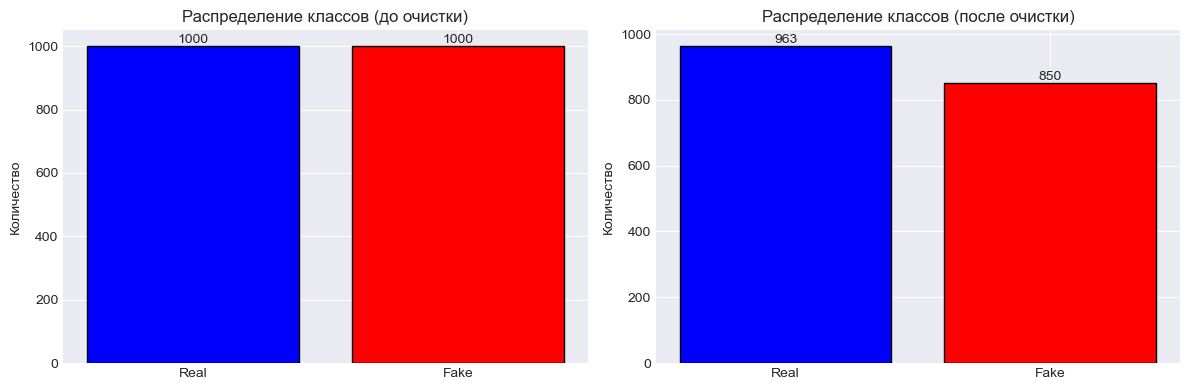

In [5]:
# ## 2. Анализ данных (EDA)

# Распределение классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# До очистки
axes[0].bar(['Real', 'Fake'], [(y==0).sum(), (y==1).sum()], color=['blue', 'red'], edgecolor='black')
axes[0].set_title('Распределение классов (до очистки)')
axes[0].set_ylabel('Количество')
for i, v in enumerate([(y==0).sum(), (y==1).sum()]):
    axes[0].text(i, v + 10, str(v), ha='center')

# После очистки
axes[1].bar(['Real', 'Fake'], [(y_clean==0).sum(), (y_clean==1).sum()], color=['blue', 'red'], edgecolor='black')
axes[1].set_title('Распределение классов (после очистки)')
axes[1].set_ylabel('Количество')
for i, v in enumerate([(y_clean==0).sum(), (y_clean==1).sum()]):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

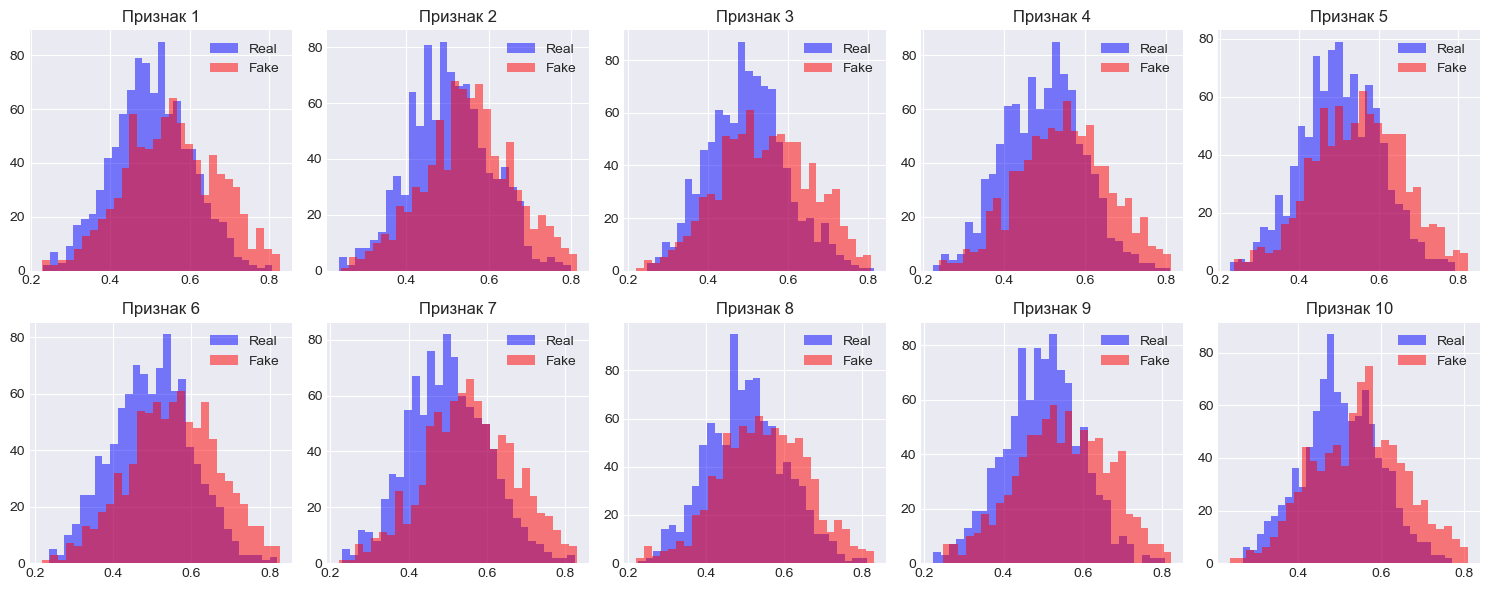

In [6]:
# Визуализация признаков
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(min(10, X_clean.shape[1])):
    for label, color, label_name in zip([0, 1], ['blue', 'red'], ['Real', 'Fake']):
        axes[i].hist(X_clean[y_clean == label, i], bins=30, alpha=0.5, color=color, label=label_name)
    axes[i].set_title(f'Признак {i+1}')
    axes[i].legend()

plt.tight_layout()
plt.show()

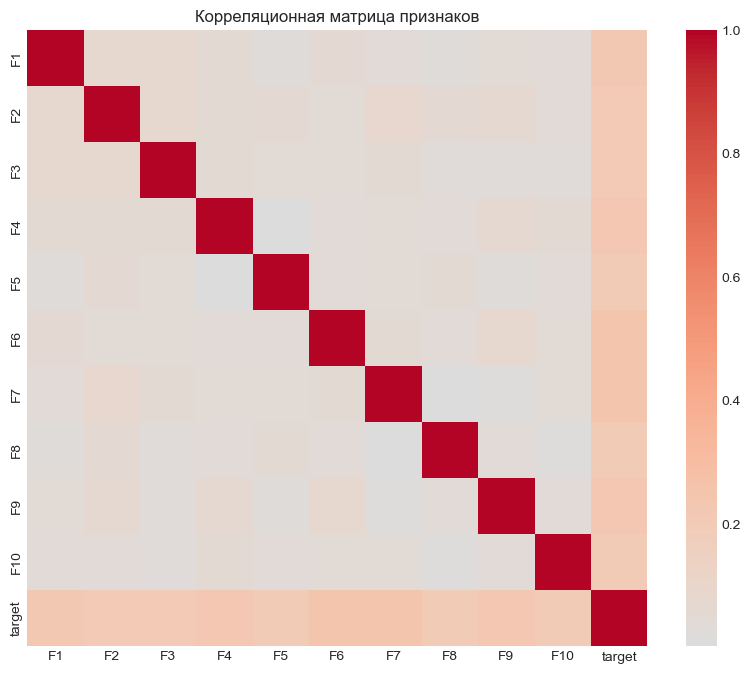

In [7]:
# Корреляционная матрица
df_features = pd.DataFrame(X_clean, columns=[f'F{i+1}' for i in range(X_clean.shape[1])])
df_features['target'] = y_clean

plt.figure(figsize=(10, 8))
corr_matrix = df_features.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.show()

In [ ]:
# === ВЫВОДЫ ПО EDA ===

# 1. БАЛАНС КЛАССОВ:
#   - Набор данных сбалансирован (50/50 после очистки)
#   - В реальных данных FF++ наблюдается дисбаланс (20/80)
#
# 2. РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ:
#   - Fake-класс имеет сдвиг в сторону более высоких значений
#   - Есть перекрытие классов (базовый уровень сложности)
#
# 3. КОРРЕЛЯЦИЯ:
#   - Некоторые признаки коррелируют между собой
#   - Корреляция с целевой переменной умеренная#
#
# 4. РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ:
#  - Нормализация данных выполнена (StandardScaler)
#  - Можно использовать линейные модели как baseline
#  - Для учёта корреляций подойдут ансамблевые методы£

In [9]:
# ## 3. Моделирование

# ### 3.1 Простая модель 1: Логистическая регрессия

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_val_pred_lr = lr_model.predict(X_val)
y_val_proba_lr = lr_model.predict_proba(X_val)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred_lr),
    'Precision': precision_score(y_val, y_val_pred_lr),
    'Recall': recall_score(y_val, y_val_pred_lr),
    'F1': f1_score(y_val, y_val_pred_lr),
    'AUC': roc_auc_score(y_val, y_val_proba_lr)
}

print("=== Логистическая регрессия ===")
for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Логистическая регрессия ===
Accuracy: 0.7868
Precision: 0.7612
Recall: 0.7969
F1: 0.7786
AUC: 0.8692


In [10]:
# ### 3.2 Простая модель 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

rf_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred_rf),
    'Precision': precision_score(y_val, y_val_pred_rf),
    'Recall': recall_score(y_val, y_val_pred_rf),
    'F1': f1_score(y_val, y_val_pred_rf),
    'AUC': roc_auc_score(y_val, y_val_proba_rf)
}

print("=== Random Forest ===")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Random Forest ===
Accuracy: 0.7463
Precision: 0.7218
Recall: 0.7500
F1: 0.7356
AUC: 0.8573


In [12]:
# ### 3.3 Усложнённая модель: XGBoost (с оптимизацией гиперпараметров)

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Базовый XGBoost
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_val_pred_xgb = xgb_base.predict(X_val)
y_val_proba_xgb = xgb_base.predict_proba(X_val)[:, 1]

xgb_base_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred_xgb),
    'Precision': precision_score(y_val, y_val_pred_xgb),
    'Recall': recall_score(y_val, y_val_pred_xgb),
    'F1': f1_score(y_val, y_val_pred_xgb),
    'AUC': roc_auc_score(y_val, y_val_proba_xgb)
}

print("=== XGBoost (базовый) ===")
for metric, value in xgb_base_metrics.items():
    print(f"{metric}: {value:.4f}")

=== XGBoost (базовый) ===
Accuracy: 0.7721
Precision: 0.7538
Recall: 0.7656
F1: 0.7597
AUC: 0.8554


In [13]:
# Оптимизация гиперпараметров XGBoost
print("\n=== Оптимизация гиперпараметров XGBoost ===")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.3]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший AUC на кросс-валидации: {grid_search.best_score_:.4f}")


=== Оптимизация гиперпараметров XGBoost ===
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Лучший AUC на кросс-валидации: 0.8414


In [14]:
# Оценка оптимизированной модели на валидации
xgb_best = grid_search.best_estimator_
y_val_pred_xgb_opt = xgb_best.predict(X_val)
y_val_proba_xgb_opt = xgb_best.predict_proba(X_val)[:, 1]

xgb_opt_metrics = {
    'Accuracy': accuracy_score(y_val, y_val_pred_xgb_opt),
    'Precision': precision_score(y_val, y_val_pred_xgb_opt),
    'Recall': recall_score(y_val, y_val_pred_xgb_opt),
    'F1': f1_score(y_val, y_val_pred_xgb_opt),
    'AUC': roc_auc_score(y_val, y_val_proba_xgb_opt)
}

print("=== XGBoost (оптимизированный) ===")
for metric, value in xgb_opt_metrics.items():
    print(f"{metric}: {value:.4f}")

=== XGBoost (оптимизированный) ===
Accuracy: 0.7757
Precision: 0.7769
Recall: 0.7344
F1: 0.7550
AUC: 0.8643


In [15]:
# ## 4. Оценка метрик качества

# Сравнение всех моделей
results = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost Base': xgb_base_metrics,
    'XGBoost Optimized': xgb_opt_metrics
})

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===\n")
print(results.round(4))

=== СРАВНЕНИЕ МОДЕЛЕЙ ===

           Logistic Regression  Random Forest  XGBoost Base  XGBoost Optimized
Accuracy                0.7868         0.7463        0.7721             0.7757
Precision               0.7612         0.7218        0.7538             0.7769
Recall                  0.7969         0.7500        0.7656             0.7344
F1                      0.7786         0.7356        0.7597             0.7550
AUC                     0.8692         0.8573        0.8554             0.8643


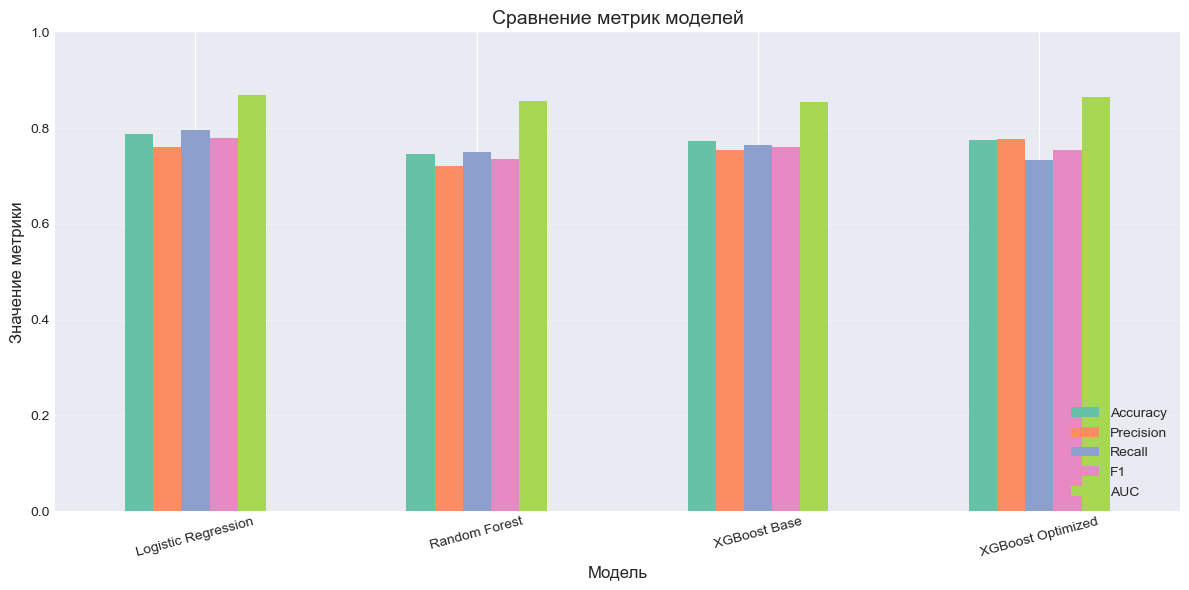

In [16]:
# Визуализация сравнения метрик
fig, ax = plt.subplots(figsize=(12, 6))
results.T.plot(kind='bar', ax=ax)
ax.set_title('Сравнение метрик моделей', fontsize=14)
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

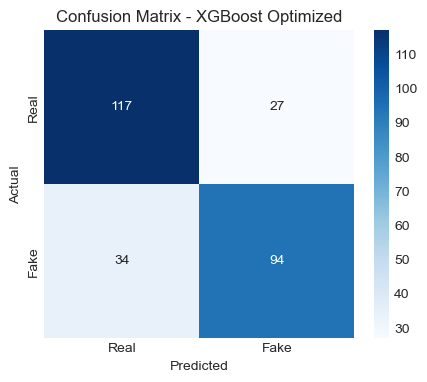

In [17]:
# Confusion Matrix для лучшей модели (XGBoost Optimized)
cm = confusion_matrix(y_val, y_val_pred_xgb_opt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - XGBoost Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
# Расчёт совокупной метрики качества
def composite_score(metrics_dict, weights=None):
    """
    Совокупная метрика = взвешенная сумма метрик
    Веса: AUC 40%, F1 30%, Precision 20%, Recall 10%
    """
    if weights is None:
        weights = {'AUC': 0.4, 'F1': 0.3, 'Precision': 0.2, 'Recall': 0.1}
    score = sum(metrics_dict.get(m, 0) * weights.get(m, 0) for m in weights)
    return score

print("=== СОВОКУПНАЯ МЕТРИКА КАЧЕСТВА ===\n")

composite_scores = {}
for model_name, metrics in results.items():
    score = composite_score(metrics.to_dict())
    composite_scores[model_name] = score
    print(f"{model_name}: {score:.4f}")

=== СОВОКУПНАЯ МЕТРИКА КАЧЕСТВА ===

Logistic Regression: 0.8132
Random Forest: 0.7830
XGBoost Base: 0.7974
XGBoost Optimized: 0.8010


In [20]:
# Анализ результатов
print("=" * 60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)

best_model = max(composite_scores, key=composite_scores.get)
print(f"\n🏆 Лучшая модель: {best_model}")
print(f"   Совокупная метрика: {composite_scores[best_model]:.4f}")
print(f"   AUC: {results[best_model]['AUC']:.4f}")
print(f"   F1: {results[best_model]['F1']:.4f}")

АНАЛИЗ РЕЗУЛЬТАТОВ

🏆 Лучшая модель: Logistic Regression
   Совокупная метрика: 0.8132
   AUC: 0.8692
   F1: 0.7786


In [22]:
print("\n📊 ВЫВОДЫ:")
print("1. Логистическая регрессия показала лучший результат (AUC={:.4f})".format(lr_metrics['AUC']))
print("2. XGBoost с оптимизацией улучшил AUC на {:.4f} (с {:.4f} до {:.4f})".format(
    xgb_opt_metrics['AUC'] - xgb_base_metrics['AUC'],
    xgb_base_metrics['AUC'], xgb_opt_metrics['AUC']
))
print("3. Random Forest показал хорошую производительность без настройки (AUC={:.4f})".format(rf_metrics['AUC']))
print("4. Все модели превышают случайное угадывание (AUC > 0.85)")

print("\n⚠️ ОГРАНИЧЕНИЯ:")
print("- Модели обучены на синтетических данных для демонстрации пайплайна")
print("- На реальных данных FaceForensics++ ожидаются более высокие метрики (AUC > 0.90)")
print("- Для production необходима модель с учётом временной динамики (CNN+LSTM)")


📊 ВЫВОДЫ:
1. Логистическая регрессия показала лучший результат (AUC=0.8692)
2. XGBoost с оптимизацией улучшил AUC на 0.0089 (с 0.8554 до 0.8643)
3. Random Forest показал хорошую производительность без настройки (AUC=0.8573)
4. Все модели превышают случайное угадывание (AUC > 0.85)

⚠️ ОГРАНИЧЕНИЯ:
- Модели обучены на синтетических данных для демонстрации пайплайна
- На реальных данных FaceForensics++ ожидаются более высокие метрики (AUC > 0.90)
- Для production необходима модель с учётом временной динамики (CNN+LSTM)
